# EDA: Análisis exploratorio de datos
El objetivo del análisis exploratorio de datos es comprender la estructura, calidad y comportamiento de las variables del dataset Contraceptive Method Choice (CMC) antes de entrenar modelos de clasificación. Esta etapa permite detectar posibles problemas de calidad de datos, entender la distribución de las clases y encontrar relaciones importantes entre las variables.

## Tarea 1: Inspección y limpieza de datos
Primero se revisó la estructura general del dataset para identificar el tipo de cada variable y determinar cuáles deben tratarse como variables numéricas y cuáles como categóricas.

El dataset contiene 1473 registros y 9 variables predictoras relacionadas con características demográficas y socioeconómicas de mujeres casadas. Aunque varias variables aparecen representadas con números enteros, muchas corresponden realmente a categorías discretas codificadas.
Por ejemplo: ``wife_edu``, ``husband_edu``, ``wife_religion``,``media_exposure`` y ``husband_occupation``representan categorías y no magnitudes continuas.

En cambio, ``wife_age``, ``num_children`` sí representan valores numéricos continuos/discretos.

No existen valores faltantes en el dataset.
No se encontraron filas duplicadas.

1. Install packages

In [1]:
pip install ucimlrepo pandas matplotlib seaborn

  Using cached ucimlrepo-0.0.7-py3-none-any.whl.metadata (5.5 kB)
  Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached certifi-2026.4.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached numpy-2.4.4-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)
   ---------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


2. Importar librerías

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

3. Importación de datasets

In [3]:
# cargar dataset desde UCI
contraceptive_method_choice = fetch_ucirepo(id=30)

# variables predictoras
X = contraceptive_method_choice.data.features

# variable objetivo
y = contraceptive_method_choice.data.targets

# unir en un solo dataframe
df = pd.concat([X, y], axis=1)

# mostrar primeras filas
df.head()

,wife_age,wife_edu,husband_edu,num_children,wife_religion,wife_working,husband_occupation,standard_of_living_index,media_exposure,contraceptive_method
0,24,2,3,3,1,1,2,3,0,1
1,45,1,3,10,1,1,3,4,0,1
2,43,2,3,7,1,1,3,4,0,1
3,42,3,2,9,1,1,3,3,0,1
4,36,3,3,8,1,1,3,2,0,1


In [ ]:
EDAfrom google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1S8kk-3BnAZH_LJPf4i3-qFNeaqEwQKkRSo5WXEBxSow/edit#gid=0


4. Ver dimensiones del dataset

In [4]:
df.shape

(1473, 10)

5. Ver tipos de datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1473 entries, 0 to 1472
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   wife_age                  1473 non-null   int64
 1   wife_edu                  1473 non-null   int64
 2   husband_edu               1473 non-null   int64
 3   num_children              1473 non-null   int64
 4   wife_religion             1473 non-null   int64
 5   wife_working              1473 non-null   int64
 6   husband_occupation        1473 non-null   int64
 7   standard_of_living_index  1473 non-null   int64
 8   media_exposure            1473 non-null   int64
 9   contraceptive_method      1473 non-null   int64
dtypes: int64(10)
memory usage: 115.2 KB


6. Verificar valores nulos

In [ ]:
df.isnull().sum()

,0
wife_age,0
wife_edu,0
husband_edu,0
num_children,0
wife_religion,0
wife_working,0
husband_occupation,0
standard_of_living_index,0
media_exposure,0
contraceptive_method,0


7. Ver nombres de columnas

In [ ]:
df.columns

Index(['wife_age', 'wife_edu', 'husband_edu', 'num_children', 'wife_religion',
       'wife_working', 'husband_occupation', 'standard_of_living_index',
       'media_exposure', 'contraceptive_method'],
      dtype='object')

## Tarea 2: Estadística descriptiva
1. **Resumen estadístico**

El resumen estadístico permite obtener una visión general de las variables numéricas del dataset.

Se observa que la edad promedio de las mujeres se encuentra alrededor de los 32 años, con valores mínimos cercanos a 16 años y máximos sobre 45 años. Esto indica que el conjunto de datos incluye mujeres en distintas etapas de vida reproductiva.

Por otra parte, el número de hijos presenta una dispersión importante. Existen mujeres sin hijos y otras con varios hijos, lo que sugiere diferencias demográficas relevantes dentro de la población estudiada.

In [ ]:
df.describe()

,wife_age,wife_edu,husband_edu,num_children,wife_religion,wife_working,husband_occupation,standard_of_living_index,media_exposure,contraceptive_method
count,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000,1473.000000
mean,32.538357,2.958588,3.429735,3.261371,0.850645,0.749491,2.137814,3.133741,0.073999,1.919891
std,8.227245,1.014994,0.816349,2.358549,0.356559,0.433453,0.864857,0.976161,0.261858,0.876376
min,16.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000
25%,26.000000,2.000000,3.000000,1.000000,1.000000,0.000000,1.000000,3.000000,0.000000,1.000000
50%,32.000000,3.000000,4.000000,3.000000,1.000000,1.000000,2.000000,3.000000,0.000000,2.000000
75%,39.000000,4.000000,4.000000,4.000000,1.000000,1.000000,3.000000,4.000000,0.000000,3.000000
max,49.000000,4.000000,4.000000,16.000000,1.000000,1.000000,4.000000,4.000000,1.000000,3.000000


2. **Analizar distribución de edades**

El análisis de la distribución de edades permite comprender cómo se concentra la población del dataset.

El histograma muestra que la mayoría de las mujeres se encuentra aproximadamente entre los 20 y 40 años, concentrándose especialmente entre los 25 y 35 años. Esto indica que el dataset representa principalmente mujeres en edad fértil activa.

También puede observarse que existen menos casos en edades extremas, tanto muy jóvenes como cercanas a los 50 años. Esta distribución es razonable considerando el contexto del uso de métodos anticonceptivos.

La variable edad podría tener una influencia importante en la clasificación, ya que las necesidades y preferencias anticonceptivas pueden cambiar según la etapa de vida.

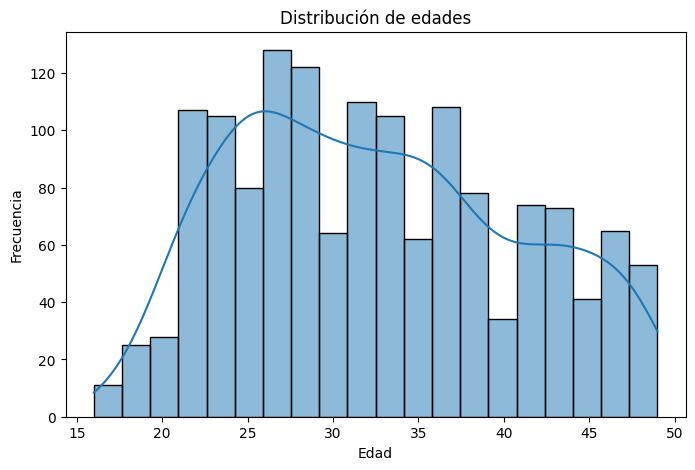

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['wife_age'], bins=20, kde=True)

plt.title('Distribución de edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()

3. **Número de hijos**

La distribución del número de hijos permite analizar las características familiares de las mujeres registradas.

El gráfico muestra que muchas mujeres tienen entre 0 y 4 hijos, aunque existen casos con cantidades mayores. La distribución presenta una tendencia asimétrica hacia la derecha, ya que hay menos mujeres con números altos de hijos.

Esta variable puede ser relevante para el problema de clasificación, debido a que la decisión sobre el uso de anticonceptivos puede relacionarse con la cantidad de hijos ya nacidos. Por ejemplo, mujeres con más hijos podrían preferir métodos anticonceptivos de larga duración.

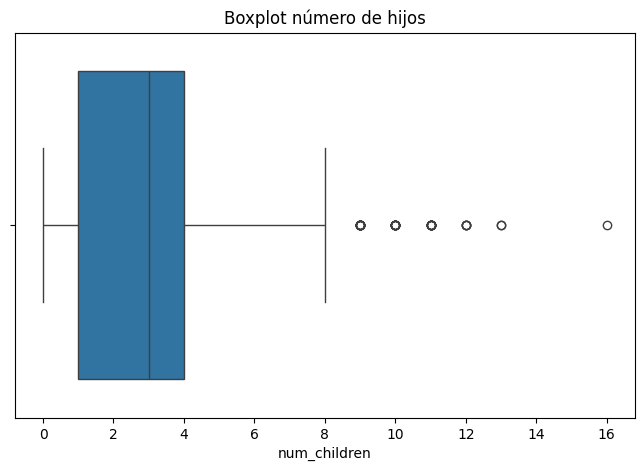

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['num_children'])

plt.title('Boxplot número de hijos')

plt.show()

4. **Distribución del método anticonceptivo**

Se analizó la variable objetivo ``contraceptive_method`` para determinar la frecuencia de cada clase.

Las tres clases corresponden a:

1. No uso de anticonceptivo
2. Método de larga duración
3. Método de corta duración

El gráfico muestra que la clase “No uso de anticonceptivos” es la más frecuente, mientras que las clases correspondientes a métodos de corto y largo plazo poseen menos registros.


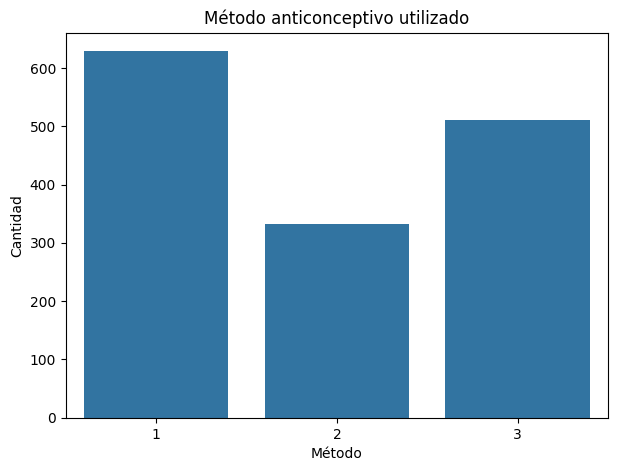

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(x='contraceptive_method', data=df)

plt.title('Método anticonceptivo utilizado')
plt.xlabel('Método')
plt.ylabel('Cantidad')

plt.show()

## Tarea 3: Relaciones entre variables

1. **Correlaciones entre variables numéricas**

El mapa de correlación permite identificar relaciones lineales entre variables numéricas del dataset.

Se observa una correlación positiva moderada entre la edad de la esposa y el número de hijos, lo cual resulta lógico, ya que mujeres de mayor edad tienden a haber tenido más hijos.

Sin embargo, debe considerarse que varias variables del dataset corresponden a categorías codificadas numéricamente. Por ello, la interpretación de correlaciones en estas variables debe realizarse con precaución, ya que los valores numéricos no representan necesariamente magnitudes continuas.

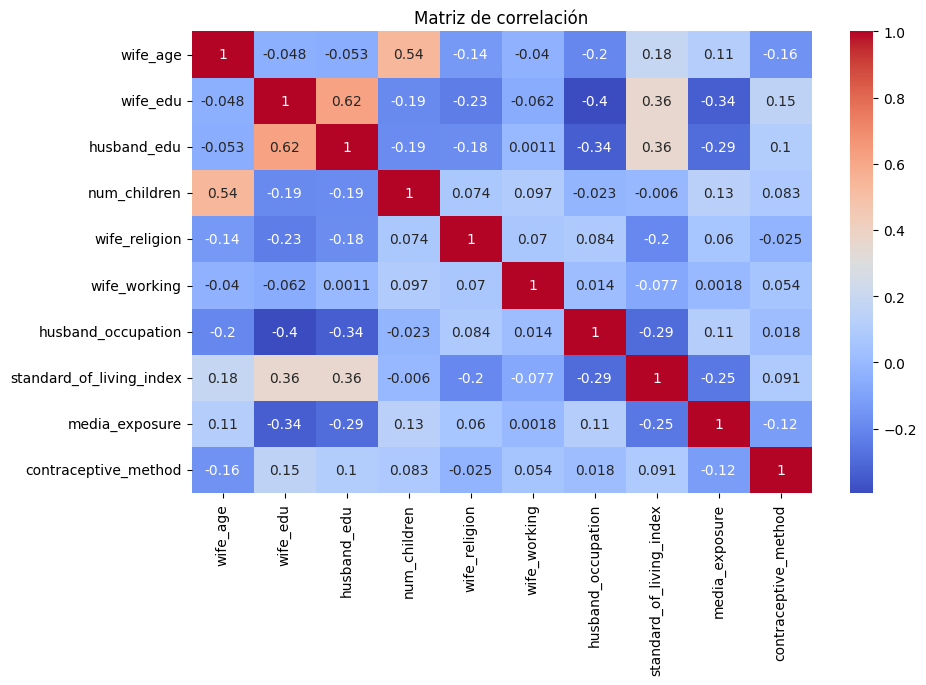

In [ ]:
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Matriz de correlación')

plt.show()

2. **Edad vs método anticonceptivo**

El análisis entre edad y método anticonceptivo permite identificar patrones de uso según el rango etario.

El gráfico muestra que las mujeres más jóvenes presentan una mayor dispersión en el uso de métodos anticonceptivos, mientras que en edades mayores aumenta la presencia de ciertos métodos específicos o incluso del no uso.

También se aprecia que algunas clases poseen rangos de edad más concentrados que otras, lo que sugiere que la edad podría ser una variable importante para la predicción del método anticonceptivo utilizado.

Esto indica que existe una posible relación entre la etapa de vida y la elección del método anticonceptivo.

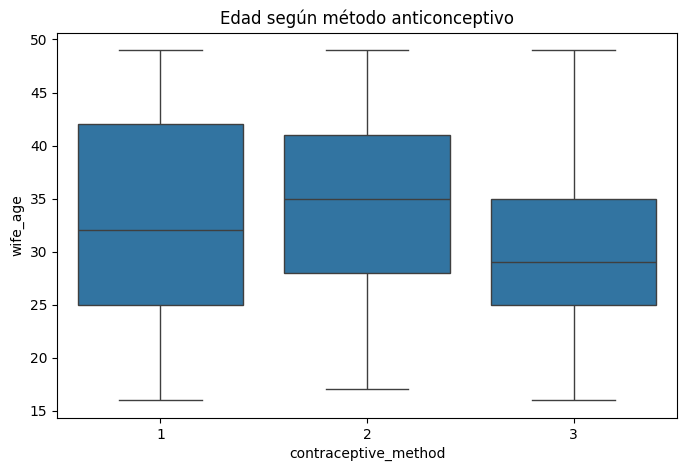

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='contraceptive_method',
    y='wife_age',
    data=df
)

plt.title('Edad según método anticonceptivo')

plt.show()

3. **Educación y método anticonceptivo**

El análisis entre nivel educacional y método anticonceptivo busca identificar si el nivel de estudios influye en la elección anticonceptiva.

El gráfico muestra diferencias en la distribución de métodos según el nivel educacional. En niveles educativos más altos se observa una mayor presencia de uso de métodos anticonceptivos en comparación con niveles educativos más bajos.

Esto podría indicar que el acceso a información, educación y servicios de salud influye en las decisiones relacionadas con planificación familiar.

Además, esta variable podría aportar capacidad predictiva al modelo de clasificación debido a la relación observable con la variable objetivo.

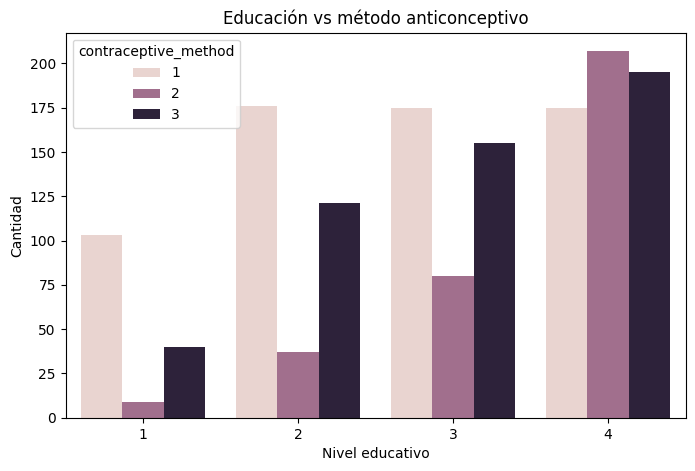

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='wife_edu',
    hue='contraceptive_method',
    data=df
)

plt.title('Educación vs método anticonceptivo')

plt.xlabel('Nivel educativo')
plt.ylabel('Cantidad')

plt.show()

4. **Relación entre hijos y método anticonceptivo**

El análisis entre número de hijos y método anticonceptivo permite estudiar cómo influye la composición familiar en la elección anticonceptiva.

El gráfico sugiere que las mujeres con mayor cantidad de hijos tienden a utilizar con más frecuencia ciertos métodos anticonceptivos, especialmente métodos de larga duración o permanentes.

En contraste, las mujeres con pocos o ningún hijo presentan una distribución más variada entre las distintas clases.

Esto sugiere que el número de hijos es una variable relevante para el problema de clasificación y podría tener un impacto significativo en el desempeño del modelo predictivo.

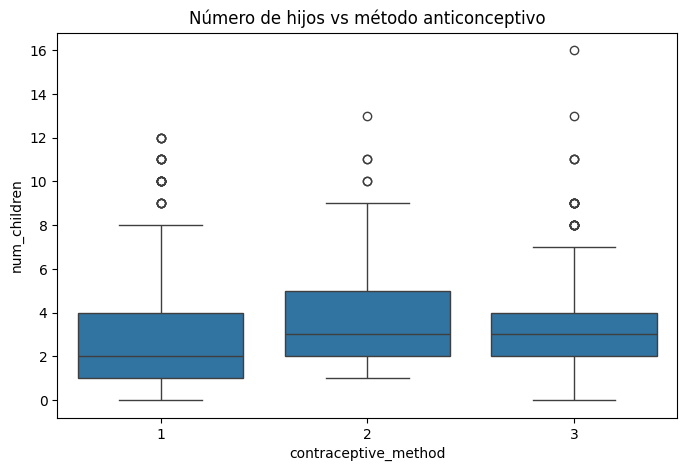

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='contraceptive_method',
    y='num_children',
    data=df
)

plt.title('Número de hijos vs método anticonceptivo')

plt.show()